# Random Forest: Xếp hạng khách hàng cho telesales

Pipeline đầy đủ: tiền xử lý → baseline → Random Forest → đánh giá → xuất danh sách gọi.
Toàn bộ dùng phiên bản dữ liệu **không có `duration`** (xem lý do ở `01_leakage_demo.ipynb`).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance
import joblib

RANDOM_STATE = 42


## 1. Đọc dữ liệu (bỏ `duration`)

In [6]:
df = pd.read_csv("data/bank/bank-full.csv", sep=";")
df = df.drop(columns=["duration"])   # BẮT BUỘC bỏ để tránh rò rỉ dữ liệu

y = (df["y"] == "yes").astype(int)
X = df.drop(columns=["y"])           # ← dòng này tạo ra X
print(X.shape, "| tỉ lệ yes:", round(y.mean(), 3))

(45211, 15) | tỉ lệ yes: 0.117


## 2. Xử lý `pdays = 999` và giá trị `'unknown'`

- `999` nghĩa là "chưa từng liên hệ" — không phải một con số ngày thật, nên tách
  thành cờ riêng để model không hiểu nhầm là "999 ngày trước".
- `'unknown'` ở `job`/`education`/`housing`... để nguyên, coi như một mức riêng
  của biến phân loại (OneHotEncoder sẽ tự xử lý như bình thường).


In [7]:
X["was_contacted_before"] = (X["pdays"] != 999).astype(int)
X["pdays"] = X["pdays"].replace(999, -1)


## 3. Chia train/test + pipeline tiền xử lý

In [8]:
cat_cols = X.select_dtypes(include="object").columns.tolist()

preprocess = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
    remainder="passthrough")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)


## 4. Baseline: Dummy & cây quyết định đơn (so sánh với TT-02)

In [9]:
def eval_model(model, name):
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    print(f"{name:20s} ROC-AUC = {auc:.3f}")
    return auc

dummy = Pipeline([("prep", preprocess),
                   ("clf", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE))])
tree = Pipeline([("prep", preprocess),
                  ("clf", DecisionTreeClassifier(max_depth=6, class_weight="balanced",
                                                  random_state=RANDOM_STATE))])

eval_model(dummy, "Dummy")
eval_model(tree, "Decision Tree")


Dummy                ROC-AUC = 0.497
Decision Tree        ROC-AUC = 0.746


0.7463547554310834

## 5. Random Forest + OOB score

In [ ]:
rf_clf = RandomForestClassifier(
    n_estimators=400,
    max_features="sqrt",
    class_weight="balanced_subsample",
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE)

rf = Pipeline([("prep", preprocess), ("clf", rf_clf)])
rf.fit(X_train, y_train)

print("OOB score:", rf.named_steps["clf"].oob_score_)
auc_rf = eval_model(rf, "Random Forest")


OOB score: 0.8929716876797169
Random Forest        ROC-AUC = 0.793


## 6. AUC theo số cây (`n_estimators`) — tìm điểm bão hoà

In [ ]:
import os
os.makedirs("../reports", exist_ok=True)  #tạo thư mục reports 
os.makedirs("../outputs", exist_ok=True)
os.makedirs("../models", exist_ok=True)

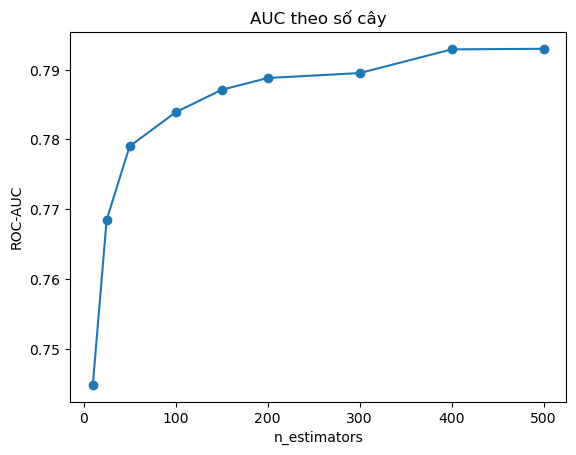

In [14]:
n_range = [10, 25, 50, 100, 150, 200, 300, 400, 500]
aucs = []

X_train_prep = preprocess.fit_transform(X_train)
X_test_prep = preprocess.transform(X_test)

for n in n_range:
    m = RandomForestClassifier(n_estimators=n, max_features="sqrt",
                                class_weight="balanced_subsample",
                                n_jobs=-1, random_state=RANDOM_STATE)
    m.fit(X_train_prep, y_train)
    aucs.append(roc_auc_score(y_test, m.predict_proba(X_test_prep)[:, 1]))

plt.plot(n_range, aucs, marker="o")
plt.xlabel("n_estimators"); plt.ylabel("ROC-AUC"); plt.title("AUC theo số cây")
plt.savefig("../reports/auc_theo_so_cay.png", dpi=120, bbox_inches="tight")
plt.show()


## 7. Feature importance: mặc định (Gini) vs Permutation

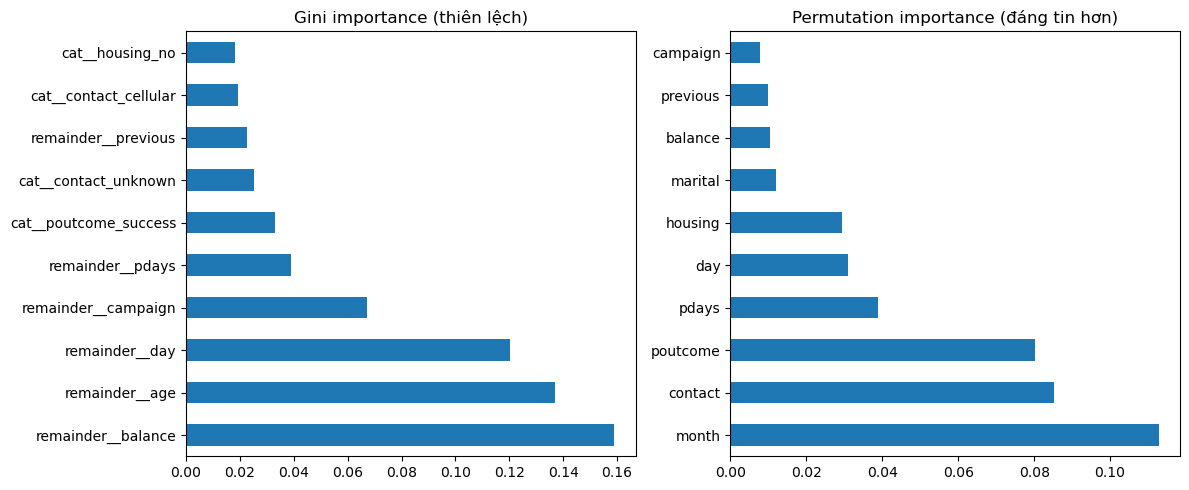

In [15]:
feat_names = rf.named_steps["prep"].get_feature_names_out()
gini_importance = pd.Series(
    rf.named_steps["clf"].feature_importances_, index=feat_names
).sort_values(ascending=False)

perm = permutation_importance(rf, X_test, y_test, n_repeats=10,
                               scoring="average_precision", random_state=RANDOM_STATE)
perm_importance = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
gini_importance.head(10).plot.barh(ax=axes[0], title="Gini importance (thiên lệch)")
perm_importance.head(10).plot.barh(ax=axes[1], title="Permutation importance (đáng tin hơn)")
plt.tight_layout()
plt.savefig("../reports/permutation_importance.png", dpi=120, bbox_inches="tight")
plt.show()


## 8. Precision@5000 và Lift — sản phẩm chính cho telesales

In [16]:
def lift_at_k(y_true, y_proba, k):
    idx = np.argsort(y_proba)[-k:]
    y_true = np.asarray(y_true)
    precision_top = y_true[idx].mean()
    lift = precision_top / y_true.mean()
    return precision_top, lift

proba_test = rf.predict_proba(X_test)[:, 1]
precision_5000, lift_5000 = lift_at_k(y_test, proba_test, k=min(5000, len(y_test)))
print(f"Precision@5000: {precision_5000:.3f}  |  Lift: {lift_5000:.2f}x so với gọi ngẫu nhiên")


Precision@5000: 0.180  |  Lift: 1.54x so với gọi ngẫu nhiên


## 9. Đường Lift / Cumulative gain

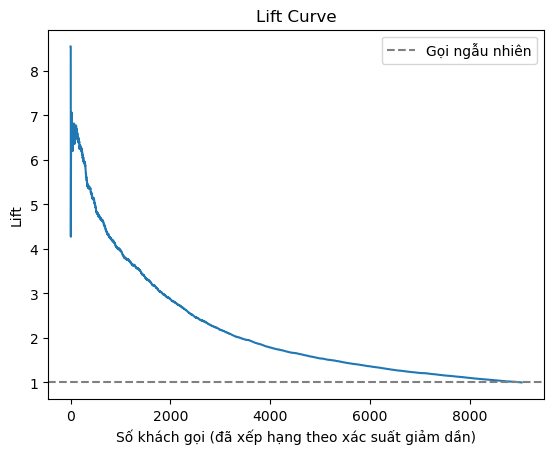

In [17]:
order = np.argsort(proba_test)[::-1]
y_sorted = np.asarray(y_test)[order]
cum_rate = np.cumsum(y_sorted) / np.arange(1, len(y_sorted) + 1)
lift_curve = cum_rate / y_test.mean()

plt.plot(lift_curve)
plt.axhline(1, color="gray", linestyle="--", label="Gọi ngẫu nhiên")
plt.xlabel("Số khách gọi (đã xếp hạng theo xác suất giảm dần)")
plt.ylabel("Lift")
plt.title("Lift Curve")
plt.legend()
plt.savefig("../reports/lift_curve.png", dpi=120, bbox_inches="tight")
plt.show()


## 10. Xuất danh sách 5.000 khách ưu tiên gọi + lưu model

In [18]:
top5000_idx = np.argsort(proba_test)[-5000:][::-1]
danh_sach = X_test.iloc[top5000_idx].copy()
danh_sach["xac_suat_dong_y"] = proba_test[top5000_idx]
danh_sach.to_csv("../outputs/danh_sach_goi_top5000.csv", index=False)

joblib.dump(rf, "../models/rf_pipeline.joblib")
print("Đã lưu: outputs/danh_sach_goi_top5000.csv và models/rf_pipeline.joblib")


Đã lưu: outputs/danh_sach_goi_top5000.csv và models/rf_pipeline.joblib
